In [ ]:
%cd nn

In [39]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [6]:
data = [[1,2,3],[4,5,6]]
arr = np.array (data)
tns = torch.tensor(data)

In [7]:
arr

array([[1, 2, 3],
       [4, 5, 6]])

In [8]:
tns

tensor([[1, 2, 3],
        [4, 5, 6]])

In [9]:
tns[1]

tensor([4, 5, 6])

In [10]:
tns[:, 1]

tensor([2, 5])

In [11]:
tns[1,1]

tensor(5)

In [12]:
tns[:, 0]

tensor([1, 4])

In [13]:
tns[1, 1:3]

tensor([5, 6])

In [14]:
tns += 1

In [15]:
tns / 1

tensor([[2., 3., 4.],
        [5., 6., 7.]])

In [16]:
tns.type()

'torch.LongTensor'

In [17]:
tns * .1

tensor([[0.2000, 0.3000, 0.4000],
        [0.5000, 0.6000, 0.7000]])

In [18]:
t = torch.rand(4, 8, 8)
t.unsqueeze(0).shape  

torch.Size([1, 4, 8, 8])

In [20]:
t.unsqueeze(1).shape  

torch.Size([4, 1, 8, 8])

In [21]:
xt = torch.tensor(3.).requires_grad_()

In [22]:
def f(x): return x**2

In [ ]:
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [24]:
yt.backward()

In [25]:
xt.grad

tensor(6.)

In [27]:
xt = torch.tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [ ]:
def f(x): return (x**2).sum()

.backward() needs a scalar to start from — it computes gradients via reverse-mode autodiff, and that process is defined starting from a single number (conceptually "how much does the final scalar change per unit change in each input"). If yt were a vector, .backward() wouldn't know how to combine gradients from multiple outputs without you supplying weights for each one.

So sum() isn't there because of some derivative rule specifically — it's there just to collapse x**2 (a vector [9, 16, 100]) into a single scalar 125 so .backward() has one number to differentiate.

Now, why does xt.grad still have 3 values, one per input element, even though yt was a single scalar?

Because gradient is "how does the output change with respect to each input," and you have 3 independent inputs. Sum doesn't merge the inputs' influence into one grad value — each x_i still gets its own partial derivative.

In [35]:
yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [36]:
yt.backward()
xt.grad

tensor([12., 16., 40.])

In [52]:
time = torch.arange(0,20).float(); time.shape

torch.Size([20])

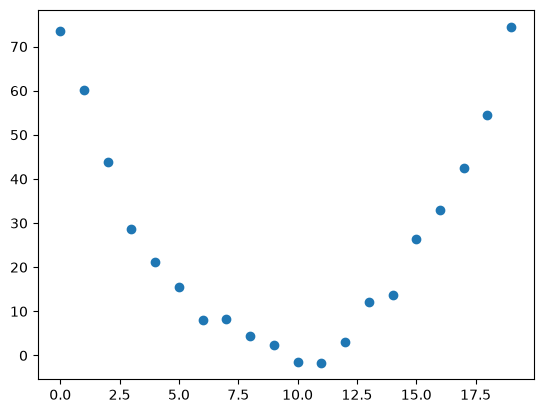

In [73]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

In [41]:
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

In [42]:
def mse(preds, targets): return ((preds-targets)**2).mean()

In [74]:
params = torch.randn(3).requires_grad_()

In [57]:
preds = f(time, params)
preds.shape

torch.Size([20])

In [71]:
def show_preds(preds, ax=None):
    preds_clone = preds.clone().detach().numpy()
    
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, preds_clone, color='red')
    ax.set_ylim(-100,100)

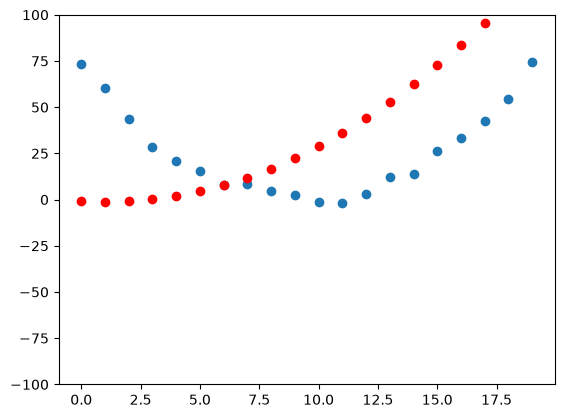

In [75]:
show_preds(preds)

In [60]:
loss = mse(preds, speed)
loss

tensor(5820.7939, grad_fn=<MeanBackward0>)

In [61]:
loss.backward()
params.grad

tensor([24004.9258,  1535.0935,    85.0139])

In [62]:
params.grad * 1e-5

tensor([0.2400, 0.0154, 0.0009])

In [63]:
params

tensor([ 0.6283, -0.9169, -0.6222], requires_grad=True)

In [ ]:
lr = 1e-4

In [65]:
params.data -= lr * params.grad.data
params.grad = None

In [66]:
preds = f(time,params)
mse(preds, speed)

tensor(1669.3176, grad_fn=<MeanBackward0>)

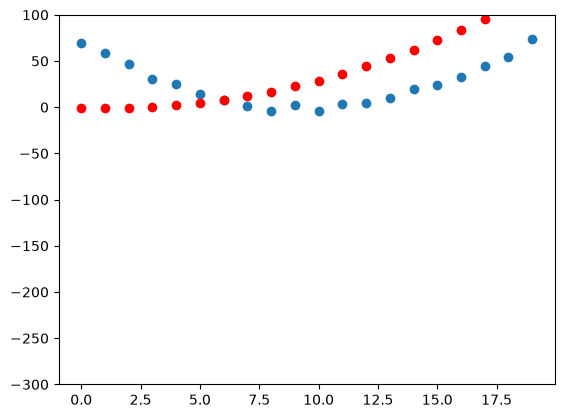

In [67]:
show_preds(preds)

In [79]:
def apply_step(params, log=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if log: print(loss.item())
    return preds

In [80]:
for i in range(10): apply_step(params)

714.8497924804688
714.8458862304688
714.842041015625
714.8382568359375
714.8344116210938
714.83056640625
714.8267822265625
714.8228759765625
714.8189697265625
714.815185546875


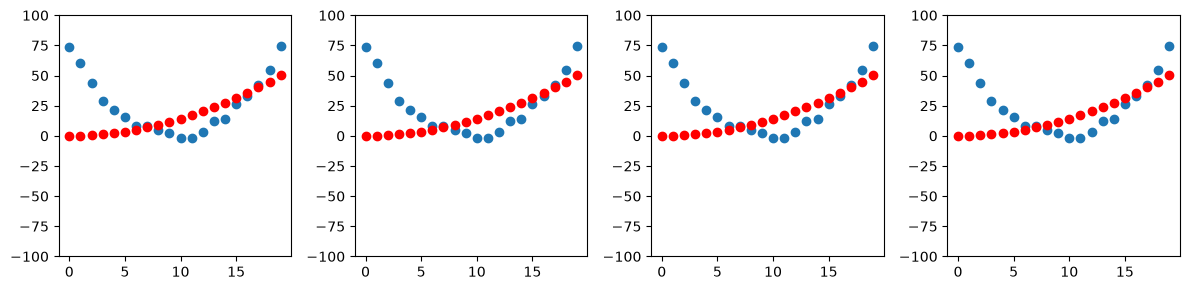

In [81]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

Imagine you are lost in the mountains with your car parked at the lowest point. To find your way back to it, you might wander in a random direction, but that probably wouldn't help much. Since you know your vehicle is at the lowest point, you would be better off going downhill. By always taking a step in the direction of the steepest downward slope, you should eventually arrive at your destination. We use the magnitude of the gradient (i.e., the steepness of the slope) to tell us how big a step to take; specifically, we multiply the gradient by a number we choose called the learning rate to decide on the step size. We then iterate until we have reached the lowest point, which will be our parking lot, then we can stop.

In [83]:
from torch.utils.data import DataLoader

coll = range(15)
dl = DataLoader(coll, batch_size=5, shuffle=True)
list(dl)

[tensor([ 6,  4, 12,  8,  9]),
 tensor([ 2,  3, 14,  1,  5]),
 tensor([13,  7,  0, 11, 10])]

In [89]:
import string

from src.utils.datasets import CustomDataset

a = enumerate(string.ascii_lowercase)
d, l = zip(*a)
ds = CustomDataset(d, l)

In [90]:
dl = DataLoader(ds, batch_size=6, shuffle=True)
list(dl)

[[tensor([22, 11,  8, 13,  6, 21]), ('w', 'l', 'i', 'n', 'g', 'v')],
 [tensor([ 4,  9, 14, 15, 20, 19]), ('e', 'j', 'o', 'p', 'u', 't')],
 [tensor([ 7,  2,  1,  0, 16, 18]), ('h', 'c', 'b', 'a', 'q', 's')],
 [tensor([23, 10,  3, 17, 25,  5]), ('x', 'k', 'd', 'r', 'z', 'f')],
 [tensor([24, 12]), ('y', 'm')]]